In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm

100%|###################################################################################| 175/175 [00:51<00:00,  3.43it/s]


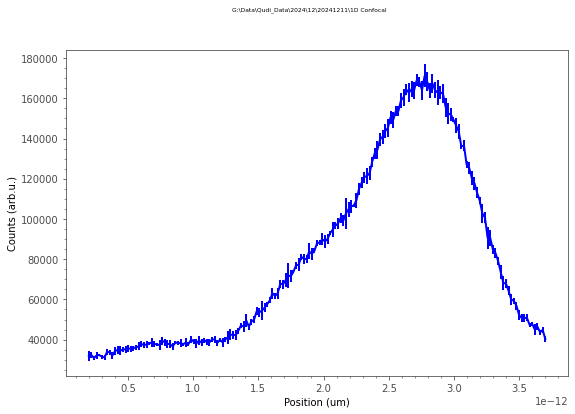

In [9]:
tip_name = 'A-H12-13'
extra = '2mV_HF_ampl'

x_start = 0.2e-6
x_stop = 3.7e-6
x_step = 175
y_pos = 6.5e-6
counter_rep = 5

counter_int_time = qafm_gui._sd.int_time_counts_sample_scan_DoubleSpinBox.value()

scan_array_x = np.linspace(x_start, x_stop, x_step)
counts = np.zeros_like(scan_array_x)
counts_err = np.zeros_like(scan_array_x)

for idx, x_pos in enumerate(tqdm(scan_array_x)):
    #set objectiv position
    afm_scanner_logic.set_obj_pos({'x': x_pos, 'y': y_pos})
    
    counts_temp = np.zeros(counter_rep)
    #measure counts
    for i in range(counter_rep):
        afm_scanner_logic._counter.countrate.startFor(int(counter_int_time*1e12), clear = True)
        afm_scanner_logic._counter.countrate.waitUntilFinished(timeout=int(counter_int_time*20*1e3))
        counts_temp[i] = np.nan_to_num(afm_scanner_logic._counter.countrate.getData())[0]
        
    counts[idx] = np.mean(counts_temp)
    counts_err[idx] = np.std(counts_temp)

fig, ax1 = plt.subplots(1,1)
ax1.errorbar(x=scan_array_x*1e6, y=counts,
                         yerr=counts_err, fmt='b-', label=f'')

ax1.set_xlabel('Position (um)')
ax1.set_ylabel('Counts (arb.u.)')

filelabel = '1D-confocal'+tip_name+'_'+extra
parameters = {'Y position (m)':y_pos, 'Counter repetitions':counter_rep, 'Counter integration time (s)': counter_int_time, "Note": ""}
data =  {'Position (m), Counts (c/s), Counts_err (c/s)': np.array((scan_array_x, counts, counts_err)).T}
filepath = savelogic.get_path_for_module(module_name='1D Confocal')
fig.suptitle(filepath, fontsize=6)
plt.show()
savelogic.save_data(data, parameters=parameters, filepath=filepath, filelabel=filelabel, plotfig=fig, delimiter='\t')

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'1D-confocal'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='1D Confocal\\')

meas_dict = {'Scan_arr_x': scan_array_x , 'Counts': counts, 'Counts_err': counts_err}

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)